In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons


/mnt/data/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /mnt/data/tmp/matplotlib-ihu9ap83 because there was an issue with the default path (/mnt/data/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [ ]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        # dim: 输入和输出的维度，默认二维
        # h: 隐藏层的宽度（隐藏单元数量）
        # self.net: 主体神经网络，输入为 (dim + 1)，输出为 dim
        # 构建一个包含三层隐藏层的前馈神经网络，每层后接ELU激活函数，输入为dim+1（拼接时间t），输出为dim
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),  # 第一层：输入(dim+1)，输出(h)
            nn.Linear(h, h), nn.ELU(),        # 第二层：输入(h)，输出(h)
            nn.Linear(h, h), nn.ELU(),        # 第三层：输入(h)，输出(h)
            nn.Linear(h, dim)                 # 输出层：输入(h)，输出(dim)
        )

    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        """
        前向传播函数

        参数:
        t: 时间步，shape:[batch_size, 1]
        x_t: 当前样本，shape:[batch_size, dim]

        返回值:
        y: shape:[batch_size, dim]
        """
        # 拼接 t 和 x_t, 作为输入，shape:[batch_size, dim+1]
        return self.net(torch.cat((t, x_t), -1))

    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        """
        执行从 t_start 到 t_end 的一步演化

        参数:
        x_t: 当前点，shape:[batch_size, dim]
        t_start: 起始时间标量，shape:[1] 或 []
        t_end: 终止时间标量，shape:[1] 或 []

        返回值:
        x_new: 更新后的点，shape:[batch_size, dim]

        说明:
        这里的 Tensor 是类型提示，表示这些参数应该是 torch.Tensor 类型，并不是必须写成这样，只是用来帮助理解/类型检查，
        不影响实际代码运行（Python 并不会强制检查类型）。
        """
        # 将 t_start 转换为形状 [batch_size, 1]，以便与每个 batch 的 x_t 对齐。
        # 因为 t_start 可能是标量或 1 元素张量，所以用 view(1, 1) 转成 [1, 1]，再 expand 到 [batch_size, 1]
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)

        # 步进更新：欧拉-中点法
        # x_t + delta_t * f( t + delta_t/2, x + f(t, x) * delta_t/2 )
        delta_t = t_end - t_start  
        mid_t = t_start + delta_t / 2 
        # self(x_t=x_t, t=t_start) 等价于 self.forward(t=t_start, x_t=x_t)
        # 由于在 forward 里 t 和 x_t 都是关键字参数，且类型和形状明确，所以调用时变量顺序没关系，只要指明名字即可
        fx = self(x_t=x_t, t=t_start)  
        mid_x = x_t + fx * (delta_t / 2)  
        return x_t + delta_t * self(
            t=mid_t,            
            x_t=mid_x           
        )

# Training

In [34]:
# 初始化 Flow 模型并放到指定设备上
flow = Flow().to(device)

# 定义优化器（Adam）和损失函数（均方误差损失）
# 迭代器（iterator）是一种可以逐个返回元素的对象，比如 for 循环中遍历列表、张量等都用到了迭代器。
# 例如 flow.parameters() 就返回一个可以遍历神经网络所有参数的迭代器。
optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

# 训练循环，迭代 10000 次
for _ in range(10000):
    #  sklearn  make_moons Make two interleaving half circles，并加上高斯噪声（noise=0.15 表示噪声标准差为 0.15，数据会变得更散开更不规则）
    
    # make_moons 默认生成"两个月亮"形状的二维数据（参见 sklearn 文档）。
    # 返回 (X, y)，X shape=[batch, 2]，y 是每个点的标签（0或1），代表属于哪一个月亮。
    # 这里我们只取 X 部分（也就是 [0]），完全不用标签 y，所以模型只看分布形状不看类别；
    # 例子:
    #   X, y = make_moons(5, noise=0.15)
    #   print(X)
    #   print(y)  # y 是 0 或 1，表示左边的月亮或右边的月亮
    x_1 = Tensor(make_moons(256, noise=0.15)[0]).to(device)
    x_0 = torch.randn_like(x_1).to(device)

    # 随机为每个样本采样一个介于 [0, 1] 之间的时间 t
    t = torch.rand(len(x_1), 1).to(device)
    
    # 线性插值得到中间态 x_t
    x_t = (1 - t) * x_0 + t * x_1
    # dx_t 就是向量场（vector field）   
    dx_t = (x_1 - x_0) 
    optimizer.zero_grad()  # 梯度清零
    # 计算损失并反向传播
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward() 
    optimizer.step()       # 更新参数
# 查看 flow 模型的参数可以如下:
# 方法 1：打印参数的名字和形状
for name, param in flow.named_parameters():
    print(f"{name}: {param.shape}")
# 方法 2：只看参数总数
total_params = sum(p.numel() for p in flow.parameters())
print("参数总数：", total_params)

net.0.weight: torch.Size([64, 3])
net.0.bias: torch.Size([64])
net.2.weight: torch.Size([64, 64])
net.2.bias: torch.Size([64])
net.4.weight: torch.Size([64, 64])
net.4.bias: torch.Size([64])
net.6.weight: torch.Size([2, 64])
net.6.bias: torch.Size([2])
参数总数： 8706


# Sampling

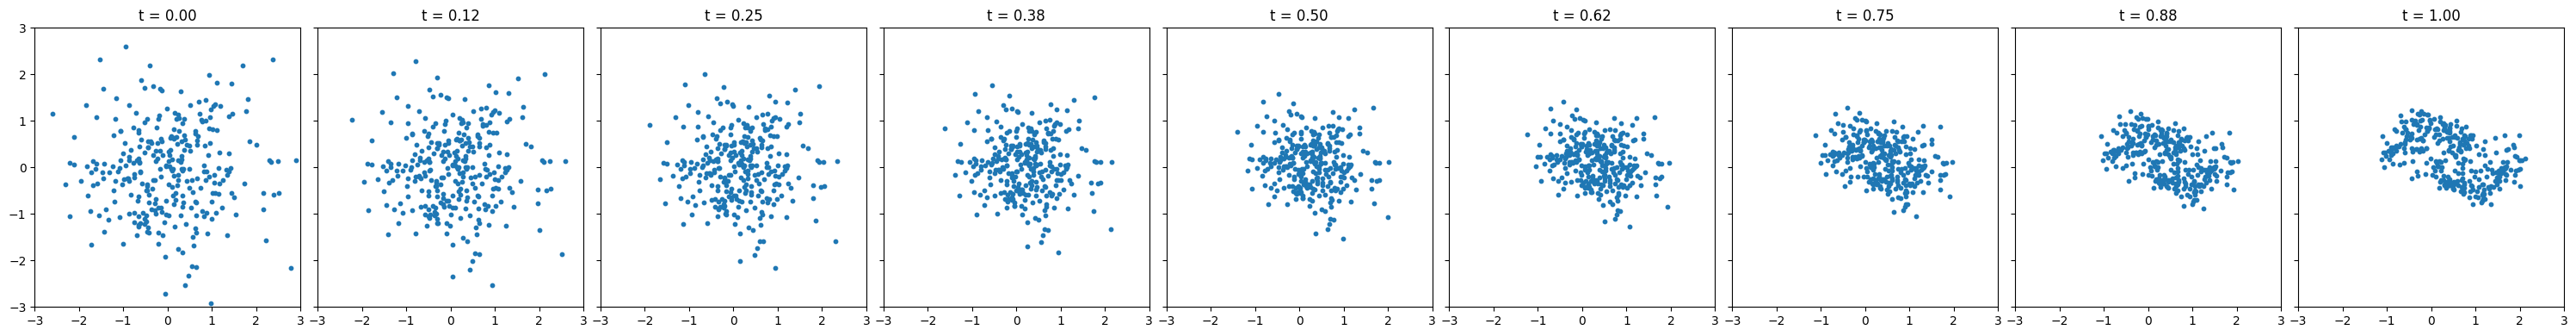

In [36]:
# 在指定 device 上用标准正态分布初始化 300 个 2D 样本
x = torch.randn(300, 2, device=device)  #  shape=[300, 2] 的张量


# 采样的步数为 8，总共 n_steps+1 个时间点
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)

# 生成从 0 到 1 的等间隔时间点
time_steps = torch.linspace(0, 1.0, n_steps + 1, device=device)

# 初始点搬回 CPU 进行画图
x_cpu = x.detach().cpu()
axes[0].scatter(x_cpu[:, 0], x_cpu[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0].item():.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

# 逐步用 flow 逆向采样，并记录每一步结果进行画图
for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    x_cpu = x.detach().cpu()
    axes[i + 1].scatter(x_cpu[:, 0], x_cpu[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1].item():.2f}')

plt.tight_layout()  # 自动调整子图参数使之填充整个区域
plt.show()

# Conditional Flow Matching
We now train a simple conditional model using class labels.

In [37]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [38]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 2, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, c: Tensor, x_t: Tensor ) -> Tensor:
        return self.net(torch.cat((t, c, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor, c: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, c = c, x_t= x_t + self(c = c, x_t=x_t, t=t_start) * (t_end - t_start) / 2)

# Training

In [ ]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    # 你理解得对，这里的“条件”是指类别标签c，而不是原始的输入x。我们通过标签（c）来区分类别，在条件流模型中，模型学习的是已知类别标签c的条件下，x的分布（即p(x|c)）。因此，标签c作为condition和时间t、x_t一起输入模型，实现按类别条件生成。
    x_1, c = make_moons(256, noise=0.15)
    x_1 = Tensor(x_1)
    c = Tensor(c).view(-1, 1)
    
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t, c=c), dx_t).backward()
    optimizer.step()

# Sampling

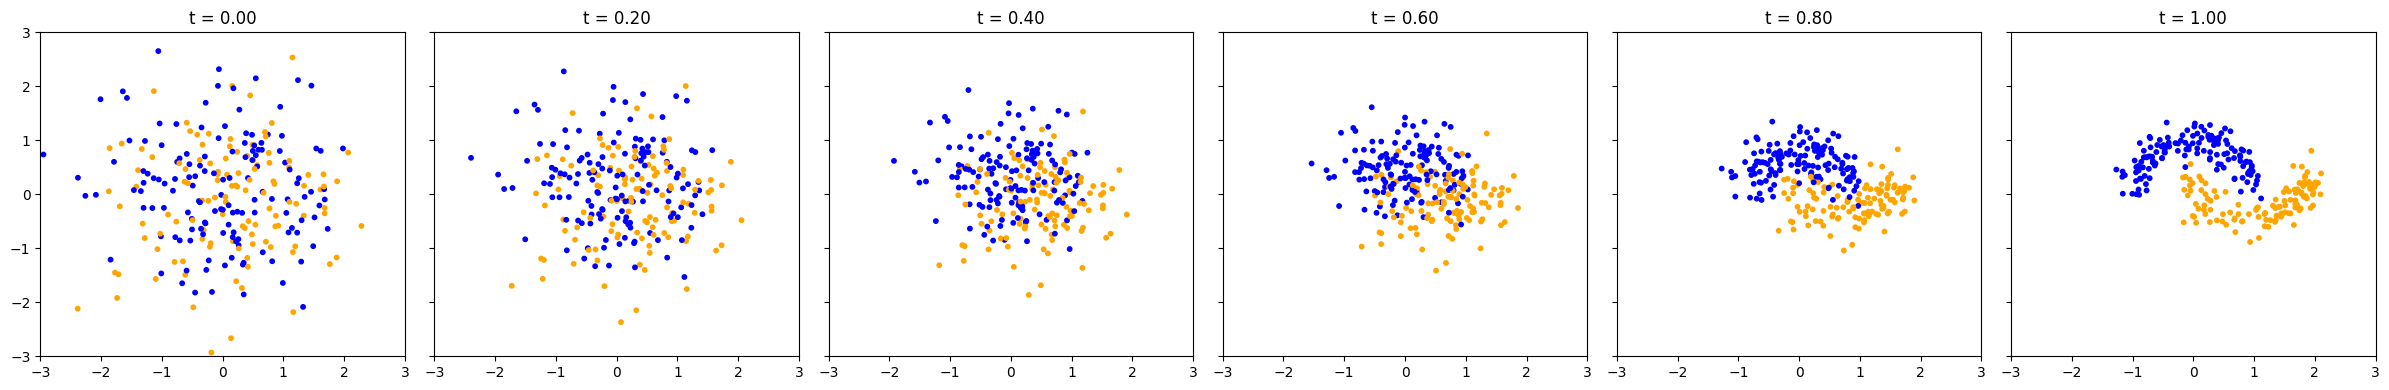

In [ ]:
# --- evaluation / visualisation section --------------------------
n_samples = 256                    

sigma = 1.0
x      = torch.randn(n_samples, 2) * sigma     # (n_samples, 2)

# if you just want random labels –– otherwise load real labels here
c_eval = torch.randint(0, 2, (n_samples, 1), dtype=torch.float32)  # (n_samples, 1)

# colours for the scatter (same length as x)
colors  = ['blue' if lbl == 0 else 'orange' for lbl in c_eval.squeeze().tolist()]

# -----------------------------------------------------------------
n_steps      = 100
plot_every   = 20
plot_indices = list(range(0, n_steps + 1, plot_every))
if plot_indices[-1] != n_steps:
    plot_indices.append(n_steps)

fig, axes   = plt.subplots(1, len(plot_indices), figsize=(4 * len(plot_indices), 4),
                           sharex=True, sharey=True)
time_steps  = torch.linspace(0, 1.0, n_steps + 1)

# initial frame
axes[0].scatter(x[:, 0], x[:, 1], s=10, c=colors)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

plot_count = 0
with torch.no_grad():                         # no gradients while sampling
    for i in range(n_steps):
        x = flow.step(x_t=x,
                      t_start=time_steps[i],
                      t_end=time_steps[i + 1],
                      c=c_eval)               # 2️⃣ use the same‑sized label tensor
        if (i + 1) in plot_indices:
            plot_count += 1
            axes[plot_count].scatter(x[:, 0], x[:, 1], s=10, c=colors)
            axes[plot_count].set_title(f't = {time_steps[i + 1]:.2f}')
            axes[plot_count].set_xlim(-3.0, 3.0)
            axes[plot_count].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()
